<a href="https://colab.research.google.com/github/abhisheksahoo6448/Google_Stock_Price_Prediction_using_fbprophet/blob/main/Google_fbprophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('GOOG_V1.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512
...,...,...,...,...,...,...,...
4853,2023-11-29,138.985001,139.669998,136.294998,136.399994,136.399994,21014700
4854,2023-11-30,136.399994,136.960007,132.789993,133.919998,133.919998,29913500
4855,2023-12-01,133.320007,133.500000,132.151993,133.320007,133.320007,24258400
4856,2023-12-04,131.294006,131.449997,129.399994,130.630005,130.630005,24117100


In [26]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4853,2023-11-29,138.985001,139.669998,136.294998,136.399994,136.399994,21014700
4854,2023-11-30,136.399994,136.960007,132.789993,133.919998,133.919998,29913500
4855,2023-12-01,133.320007,133.500000,132.151993,133.320007,133.320007,24258400
4856,2023-12-04,131.294006,131.449997,129.399994,130.630005,130.630005,24117100
4857,2023-12-05,130.369995,133.539993,129.729996,132.389999,132.389999,19216500


In [3]:
!pip install prophet

In [4]:
from prophet import Prophet

In [5]:
from prophet.plot import plot_plotly, plot_components_plotly

In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [7]:
df1 = df[['Date', 'Close']]

In [8]:
df1.columns

Index(['Date', 'Close'], dtype='object')

In [9]:
df1.columns = ['ds', 'y']

In [10]:
df1.columns

Index(['ds', 'y'], dtype='object')

<Axes: xlabel='ds'>

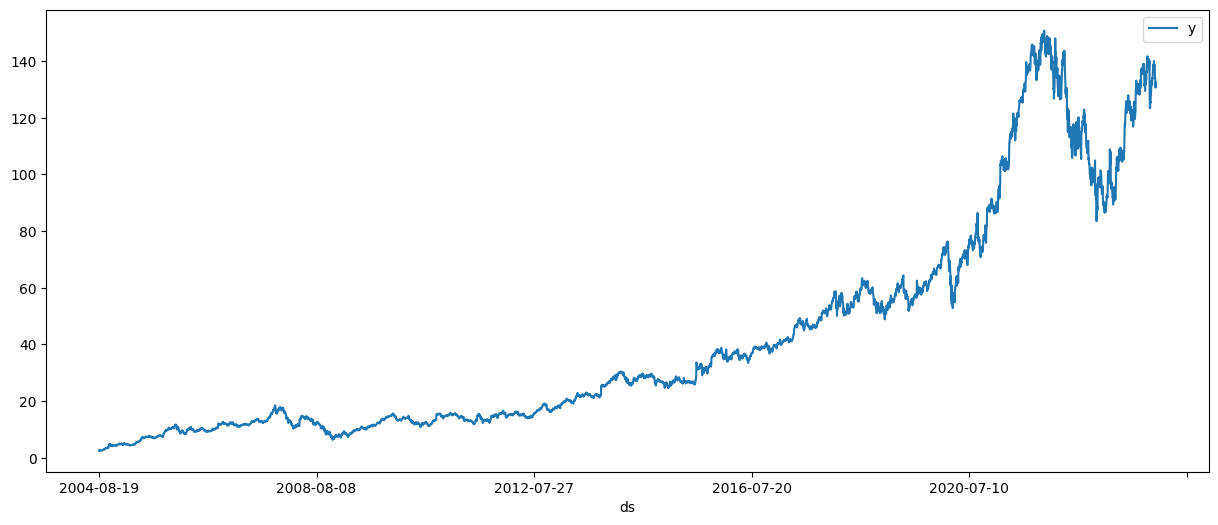

In [11]:
df1.plot(x = 'ds', y = 'y', figsize = (15,6))

In [13]:
len(df1)

4858

In [14]:
len(df1)-365

4493

In [15]:
train = df1.iloc[:len(df1)-365]
test = df1.iloc[len(df1)-365:]

In [16]:
m = Prophet()

In [17]:
m.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [27]:
forecast = m.make_future_dataframe(periods = 730)

In [28]:
predict = m.predict(forecast)

In [29]:
predict

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2004-08-19,3.080565,-3.816634,11.347310,3.080565,3.080565,0.813876,0.813876,0.813876,0.139843,0.139843,0.139843,0.674033,0.674033,0.674033,0.0,0.0,0.0,3.894441
1,2004-08-20,3.091407,-3.663372,11.845814,3.091407,3.091407,0.839130,0.839130,0.839130,0.158468,0.158468,0.158468,0.680662,0.680662,0.680662,0.0,0.0,0.0,3.930537
2,2004-08-23,3.123935,-3.956231,12.087199,3.123935,3.123935,0.798989,0.798989,0.798989,0.092042,0.092042,0.092042,0.706947,0.706947,0.706947,0.0,0.0,0.0,3.922924
3,2004-08-24,3.134778,-4.037195,11.827010,3.134778,3.134778,0.792233,0.792233,0.792233,0.075433,0.075433,0.075433,0.716800,0.716800,0.716800,0.0,0.0,0.0,3.927011
4,2004-08-25,3.145620,-3.343047,11.980734,3.145620,3.145620,0.865934,0.865934,0.865934,0.139294,0.139294,0.139294,0.726640,0.726640,0.726640,0.0,0.0,0.0,4.011554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5218,2024-06-18,193.718062,176.993843,205.504188,181.452726,205.196904,-1.544481,-1.544481,-1.544481,0.075433,0.075433,0.075433,-1.619914,-1.619914,-1.619914,0.0,0.0,0.0,192.173582
5219,2024-06-19,193.791965,177.521018,205.663313,181.502127,205.295940,-1.446277,-1.446277,-1.446277,0.139294,0.139294,0.139294,-1.585571,-1.585571,-1.585571,0.0,0.0,0.0,192.345688
5220,2024-06-20,193.865868,177.688357,206.431804,181.551528,205.394975,-1.406458,-1.406458,-1.406458,0.139843,0.139843,0.139843,-1.546301,-1.546301,-1.546301,0.0,0.0,0.0,192.459410
5221,2024-06-21,193.939770,178.208689,206.914350,181.600929,205.494011,-1.343332,-1.343332,-1.343332,0.158468,0.158468,0.158468,-1.501800,-1.501800,-1.501800,0.0,0.0,0.0,192.596438


In [30]:
df2 = predict[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

In [31]:
df2.tail()

,ds,yhat,yhat_lower,yhat_upper
5218,2024-06-18,192.173582,176.993843,205.504188
5219,2024-06-19,192.345688,177.521018,205.663313
5220,2024-06-20,192.459410,177.688357,206.431804
5221,2024-06-21,192.596438,178.208689,206.914350
5222,2024-06-22,192.259298,178.047797,206.196223


In [32]:
plot_plotly(m,predict)

In [33]:
plot_components_plotly(m,predict)

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.

